In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

discos = pd.read_parquet("/home/darshani/lightkurve-env/space-debris-detector/data/cleaned/discos_cleaned.parquet")

print(discos.shape)
print(discos.columns.tolist())
discos.head()

(89749, 31)
['type', 'id', 'attr_cosparId', 'attr_vimpelId', 'attr_satno', 'attr_name', 'attr_objectClass', 'attr_mass', 'attr_shape', 'attr_width', 'attr_height', 'attr_depth', 'attr_diameter', 'attr_span', 'attr_xSectMax', 'attr_xSectMin', 'attr_xSectAvg', 'attr_firstEpoch', 'attr_mission', 'attr_predDecayDate', 'attr_active', 'attr_cataloguedFragments', 'attr_onOrbitCataloguedFragments', 'rel_launch', 'rel_reentry', 'rel_initialOrbits', 'rel_destinationOrbits', 'rel_states', 'rel_operators', 'rel_tags', 'rel_constellations']


,type,id,attr_cosparId,attr_vimpelId,attr_satno,attr_name,attr_objectClass,attr_mass,attr_shape,attr_width,...,attr_cataloguedFragments,attr_onOrbitCataloguedFragments,rel_launch,rel_reentry,rel_initialOrbits,rel_destinationOrbits,rel_states,rel_operators,rel_tags,rel_constellations
0,object,900,1964-063C,NaN,900.0,Calsphere 1,Payload,0.99,Sphere,NaN,...,0,0,{'links': {'self': '/api/objects/900/relations...,{'links': {'self': '/api/objects/900/relations...,{'links': {'self': '/api/objects/900/relations...,{'links': {'self': '/api/objects/900/relations...,{'links': {'self': '/api/objects/900/relations...,{'links': {'self': '/api/objects/900/relations...,{'links': {'self': '/api/objects/900/relations...,{'links': {'self': '/api/objects/900/relations...
1,object,902,1964-063E,NaN,902.0,Calsphere 2,Payload,9.71,Sphere,0.36,...,0,0,{'links': {'self': '/api/objects/902/relations...,{'links': {'self': '/api/objects/902/relations...,{'links': {'self': '/api/objects/902/relations...,{'links': {'self': '/api/objects/902/relations...,{'links': {'self': '/api/objects/902/relations...,{'links': {'self': '/api/objects/902/relations...,{'links': {'self': '/api/objects/902/relations...,{'links': {'self': '/api/objects/902/relations...
2,object,1361,1965-034C,NaN,1361.0,LCS 1,Payload,33.70,Sphere,1.13,...,0,0,{'links': {'self': '/api/objects/1361/relation...,{'links': {'self': '/api/objects/1361/relation...,{'links': {'self': '/api/objects/1361/relation...,{'links': {'self': '/api/objects/1361/relation...,{'links': {'self': '/api/objects/1361/relation...,{'links': {'self': '/api/objects/1361/relation...,{'links': {'self': '/api/objects/1361/relation...,{'links': {'self': '/api/objects/1361/relation...
3,object,1512,1965-065E,NaN,1512.0,Tempsat 1,Payload,8.92,Sphere,0.36,...,0,0,{'links': {'self': '/api/objects/1512/relation...,{'links': {'self': '/api/objects/1512/relation...,{'links': {'self': '/api/objects/1512/relation...,{'links': {'self': '/api/objects/1512/relation...,{'links': {'self': '/api/objects/1512/relation...,{'links': {'self': '/api/objects/1512/relation...,{'links': {'self': '/api/objects/1512/relation...,{'links': {'self': '/api/objects/1512/relation...
4,object,1520,1965-065H,NaN,1520.0,Calsphere 4,Payload,4.00,Sphere,0.40,...,0,0,{'links': {'self': '/api/objects/1520/relation...,{'links': {'self': '/api/objects/1520/relation...,{'links': {'self': '/api/objects/1520/relation...,{'links': {'self': '/api/objects/1520/relation...,{'links': {'self': '/api/objects/1520/relation...,{'links': {'self': '/api/objects/1520/relation...,{'links': {'self': '/api/objects/1520/relation...,{'links': {'self': '/api/objects/1520/relation...


In [2]:
print("object classes:\n", discos['attr_objectClass'].value_counts())
print("\nshapes:\n", discos['attr_shape'].value_counts().head(10))
print("\nmass nulls:", discos['attr_mass'].isna().sum())
print("active counts:\n", discos['attr_active'].value_counts())

object classes:
 attr_objectClass
Payload                           27197
Payload Fragmentation Debris      17056
Rocket Fragmentation Debris       14423
Unknown                           13457
Rocket Body                        8532
Payload Mission Related Object     4166
Rocket Mission Related Object      4122
Payload Debris                      370
Rocket Debris                       266
Other Debris                        160
Name: count, dtype: int64

shapes:
 attr_shape
None                51579
Box + 2 Pan          9605
Cyl                  8821
Box + 1 Pan          5409
Box                  2691
Sphere               1612
Cone                 1152
Cyl + 1 Nozzle        800
Trap Box + 2 Pan      759
Sphere + Cyl          758
Name: count, dtype: int64

mass nulls: 50756
active counts:
 attr_active
None     74705
True     14683
False      361
Name: count, dtype: int64


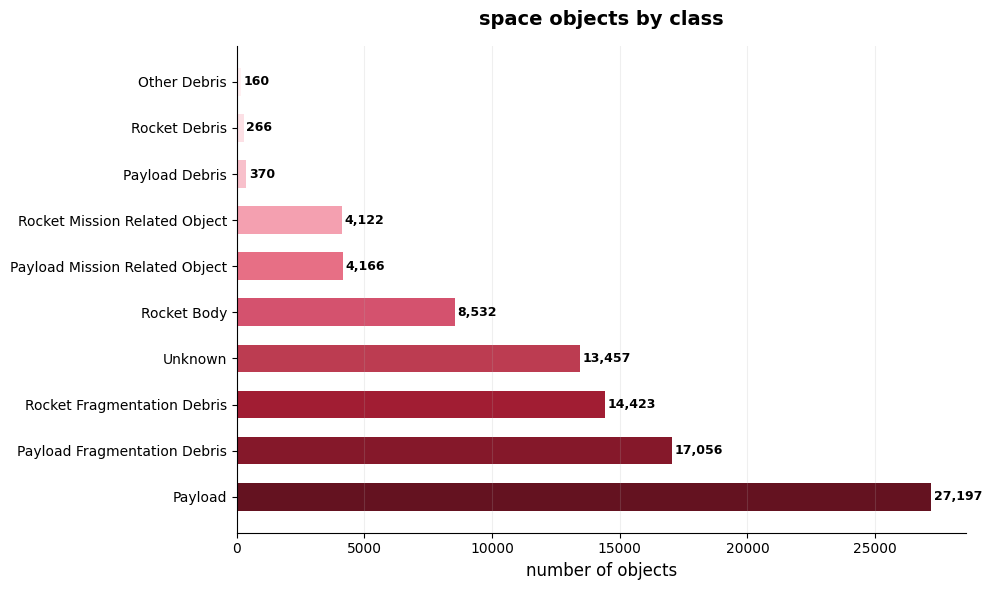

In [3]:
fig, ax = plt.subplots(figsize=(10, 6))

counts = discos['attr_objectClass'].value_counts()

colors = ['#641220', '#85182a', '#a11d33', '#bc3c51', '#d4526e', '#e76f85', '#f4a0b0', '#f8c0cb', '#fce0e5', '#fff0f2']

bars = ax.barh(counts.index, counts.values, color=colors[:len(counts)], edgecolor='none', height=0.6)

for bar, val in zip(bars, counts.values):
    ax.text(val + 100, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9, fontweight='bold')

ax.set_title('space objects by class', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('number of objects', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', alpha=0.2)
plt.tight_layout()
plt.show()

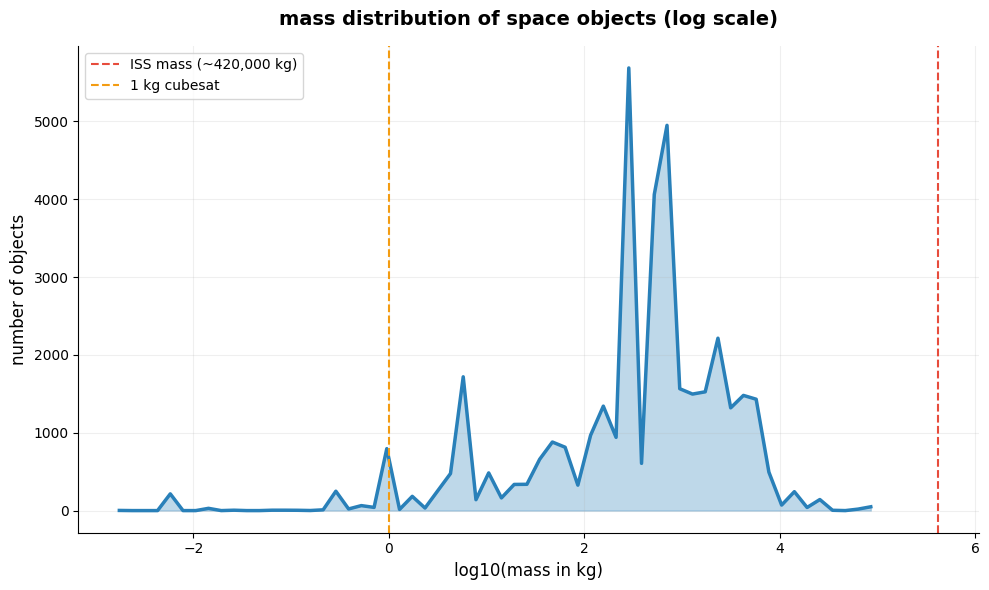

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))

mass = pd.to_numeric(discos['attr_mass'], errors='coerce').dropna()
mass = mass[(mass > 0) & (mass < 100000)]
log_mass = np.log10(mass)

counts, bins = np.histogram(log_mass, bins=60)
bin_centers = (bins[:-1] + bins[1:]) / 2

ax.plot(bin_centers, counts, color='#2980b9', linewidth=2.5)
ax.fill_between(bin_centers, counts, alpha=0.3, color='#2980b9')

ax.axvline(x=np.log10(420000), color='#e74c3c', linestyle='--', linewidth=1.5, label='ISS mass (~420,000 kg)')
ax.axvline(x=np.log10(1), color='#f39c12', linestyle='--', linewidth=1.5, label='1 kg cubesat')

ax.set_title('mass distribution of space objects (log scale)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('log10(mass in kg)', fontsize=12)
ax.set_ylabel('number of objects', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

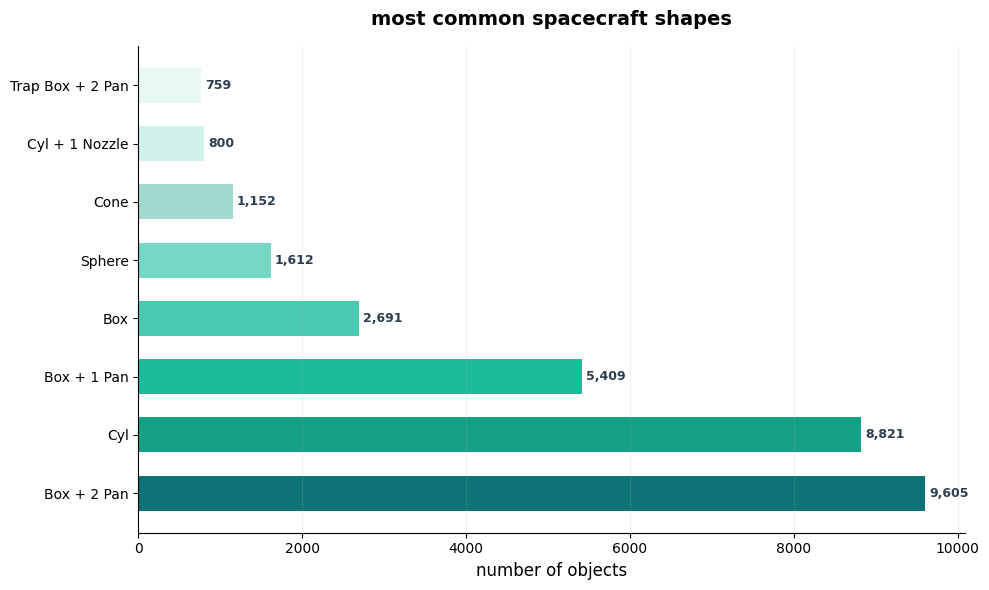

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))

shapes = discos['attr_shape'].replace('None', np.nan).dropna().value_counts().head(8)

colors = ['#0d7377', '#14a085', '#1abc9c', '#48c9b0', '#76d7c4', '#a2d9ce', '#d1f2eb', '#e8f8f5']

bars = ax.barh(shapes.index, shapes.values, color=colors, edgecolor='none', height=0.6)

for bar, val in zip(bars, shapes.values):
    ax.text(val + 50, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9, fontweight='bold', color='#2c3e50')

ax.set_title('most common spacecraft shapes', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('number of objects', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', alpha=0.2)
plt.tight_layout()
plt.show()

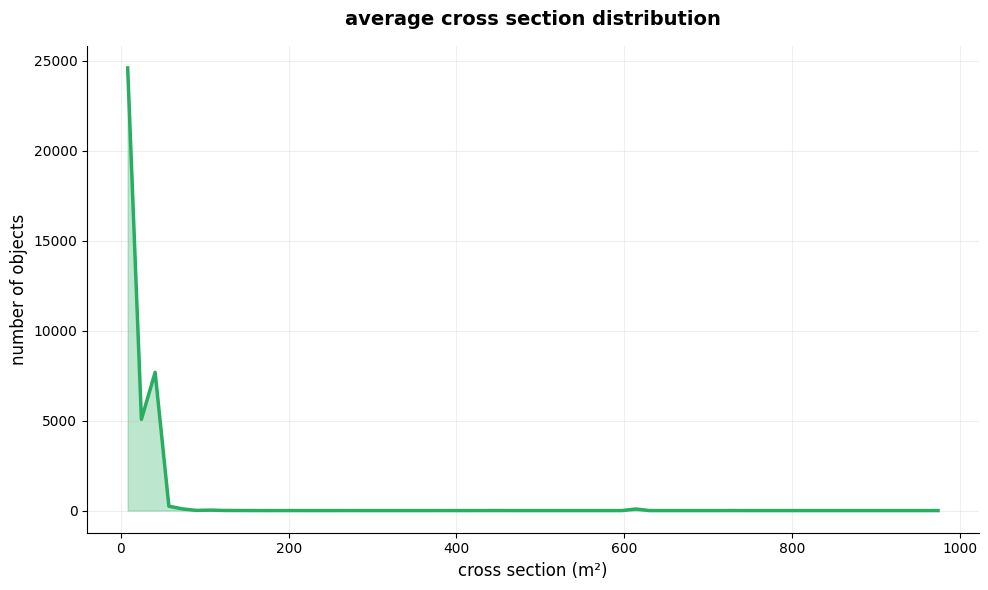

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))

xsect = pd.to_numeric(discos['attr_xSectAvg'], errors='coerce').dropna()
xsect = xsect[(xsect > 0) & (xsect < 1000)]

counts, bins = np.histogram(xsect, bins=60)
bin_centers = (bins[:-1] + bins[1:]) / 2

ax.plot(bin_centers, counts, color='#27ae60', linewidth=2.5)
ax.fill_between(bin_centers, counts, alpha=0.3, color='#27ae60')

ax.set_title('average cross section distribution', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('cross section (m²)', fontsize=12)
ax.set_ylabel('number of objects', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

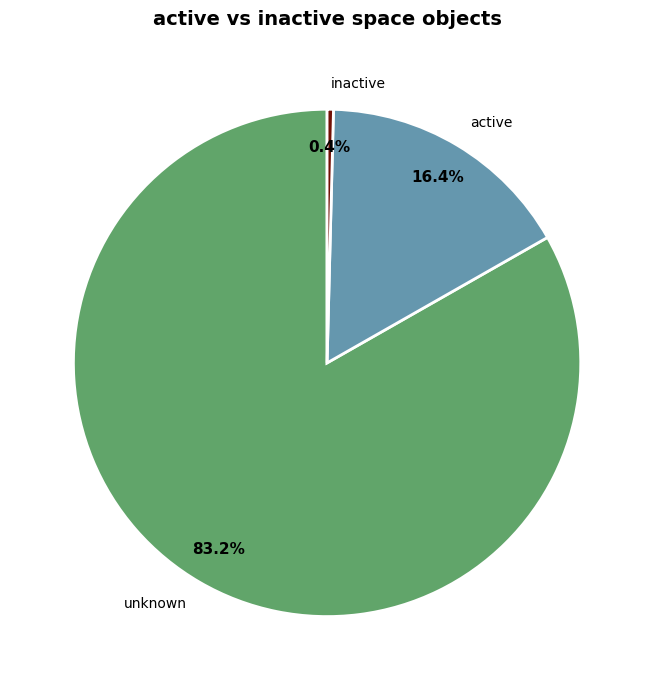

In [7]:
fig, ax = plt.subplots(figsize=(7, 7))

active = discos['attr_active'].value_counts()
active.index = ['unknown', 'active', 'inactive']
colors = ["#61a56a", "#6597ae", "#720f04"]

wedges, texts, autotexts = ax.pie(active.values, labels=active.index,
                                   colors=colors, autopct='%1.1f%%',
                                   startangle=90, pctdistance=0.85,
                                   wedgeprops=dict(edgecolor='white', linewidth=2))

for text in autotexts:
    text.set_fontweight('bold')
    text.set_fontsize(11)

ax.set_title('active vs inactive space objects', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()